# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

   Data yang digunakan berupa data COVID 19 Indonesia dari kaggle.

   https://www.kaggle.com/datasets/hendratno/covid19-indonesia/versions/82




# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import  silhouette_score
from sklearn.decomposition import PCA
import os

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv("covid_19_indonesia_time_series_all_raw.csv")
df.head()

,Date,Location ISO Code,Location,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,...,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Case Fatality Rate,Case Recovered Rate,Growth Factor of New Cases,Growth Factor of New Deaths
0,3/1/2020,ID-JK,DKI Jakarta,2,0,0,2,39,20,39,...,-6.204699,0.18,3.60,0.0,1.84,0.18,51.28%,100.00%,NaN,NaN
1,3/2/2020,ID-JK,DKI Jakarta,2,0,0,2,41,20,39,...,-6.204699,0.18,3.78,0.0,1.84,0.18,48.78%,95.12%,1.0,1.0
2,3/2/2020,IDN,Indonesia,2,0,0,2,2,0,0,...,-0.789275,0.01,0.01,0.0,0.00,0.00,0.00%,0.00%,NaN,NaN
3,3/2/2020,ID-RI,Riau,1,0,0,1,2,0,0,...,0.511648,0.16,0.33,0.0,0.00,0.00,0.00%,0.00%,NaN,NaN
4,3/3/2020,ID-JK,DKI Jakarta,2,0,0,2,43,20,39,...,-6.204699,0.18,3.96,0.0,1.84,0.18,46.51%,90.70%,1.0,1.0


# **4. Exploratory Data Analysis (EDA)**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20816 entries, 0 to 20815
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         20816 non-null  object 
 1   Location ISO Code            20816 non-null  object 
 2   Location                     20816 non-null  object 
 3   New Cases                    20816 non-null  int64  
 4   New Deaths                   20816 non-null  int64  
 5   New Recovered                20816 non-null  int64  
 6   New Active Cases             20816 non-null  int64  
 7   Total Cases                  20816 non-null  int64  
 8   Total Deaths                 20816 non-null  int64  
 9   Total Recovered              20816 non-null  int64  
 10  Total Active Cases           20816 non-null  int64  
 11  Location Level               20816 non-null  object 
 12  City or Regency              0 non-null      float64
 13  Province        

In [4]:
df.describe()

,New Cases,New Deaths,New Recovered,New Active Cases,Total Cases,Total Deaths,Total Recovered,Total Active Cases,City or Regency,Total Regencies,...,Population Density,Longitude,Latitude,New Cases per Million,Total Cases per Million,New Deaths per Million,Total Deaths per Million,Total Deaths per 100rb,Growth Factor of New Cases,Growth Factor of New Deaths
count,20816.000000,20816.000000,20816.000000,20816.000000,2.081600e+04,20816.000000,2.081600e+04,20816.000000,0.0,20816.000000,...,20816.000000,20816.000000,20816.000000,20816.000000,20816.000000,20816.000000,20816.000000,20816.000000,19709.000000,18449.000000
mean,408.078257,13.784829,393.044341,1.249087,7.788760e+04,2388.498463,6.935489e+04,6144.216132,NaN,24.155073,...,745.753554,113.682529,-2.730658,30.650065,5639.051564,0.888246,147.020981,14.702046,1.402367,1.080908
std,2119.450324,78.146224,2042.353301,958.146043,3.417859e+05,10758.160910,3.124817e+05,28108.333301,NaN,68.699338,...,2744.954621,9.856053,3.609097,71.250664,9614.992076,2.321385,233.384058,23.338412,3.131338,1.608258
min,0.000000,0.000000,0.000000,-25725.000000,1.000000e+00,0.000000,0.000000e+00,-2305.000000,NaN,1.000000,...,8.590000,96.910522,-8.682205,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.000000,0.000000,4.000000,-17.000000,1.579500e+03,43.000000,8.730000e+02,217.000000,NaN,7.000000,...,47.790000,106.109004,-6.204699,2.240000,361.042500,0.000000,9.200000,0.920000,0.660000,0.630000
50%,45.000000,1.000000,35.000000,1.000000,9.827000e+03,253.000000,7.739000e+03,1002.000000,NaN,11.000000,...,103.840000,113.417654,-2.461746,9.010000,2423.560000,0.190000,68.220000,6.820000,0.990000,1.000000
75%,161.000000,5.000000,152.000000,29.000000,3.363625e+04,949.000000,2.918100e+04,2748.250000,NaN,18.000000,...,262.700000,121.201093,0.212037,27.610000,6701.827500,0.760000,175.712500,17.572500,1.330000,1.000000
max,56757.000000,2069.000000,48832.000000,36726.000000,4.247320e+06,143519.000000,4.092586e+06,574135.000000,NaN,416.000000,...,16334.310000,138.696030,4.225615,1348.130000,79481.050000,63.800000,1533.420000,153.340000,175.000000,134.500000


In [14]:
df_group = df.groupby("Location").sum()
display(df_group)

,Total Cases,Total Deaths,Total Recovered
Location,,,
Aceh,6859110,304723,5543320
Bali,20704740,633972,18464762
Banten,23296668,532118,21179286
Bengkulu,3805398,84268,3381532
DKI Jakarta,185288197,3053873,174551316
Daerah Istimewa Yogyakarta,23921106,711975,20481657
Gorontalo,2546672,81930,2308832
Jambi,4593451,100675,3907638
Jawa Barat,131520919,2255769,117533125


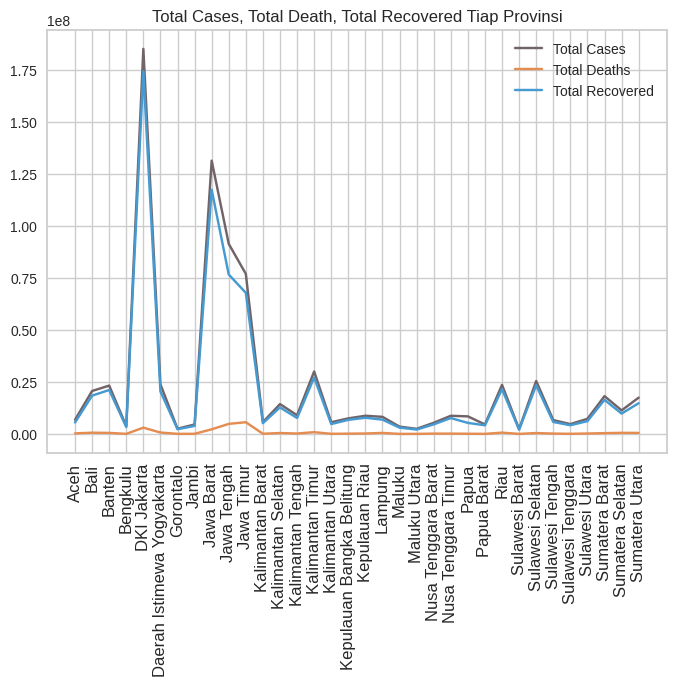

In [15]:
fig, ax = plt.subplots()

for label, group in df_group.items():
    color = np.random.rand(3,)
    ax.plot(group, label=label, color=color)

ax.tick_params(axis='x', labelsize=12, labelrotation=90)
ax.legend()
plt.title('Total Cases, Total Death, Total Recovered Tiap Provinsi')
plt.show()


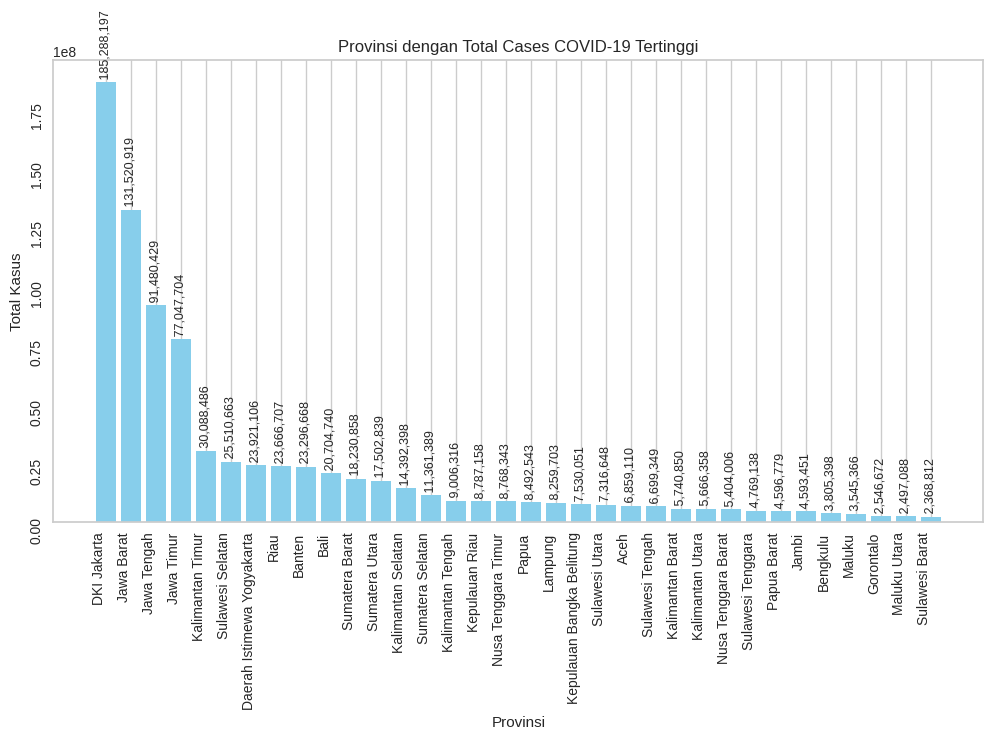

In [16]:
df_sorted = df_group.sort_values('Total Cases', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(df_sorted.index, df_sorted['Total Cases'], color='skyblue')
plt.title('Provinsi dengan Total Cases COVID-19 Tertinggi')
plt.xlabel('Provinsi')
plt.ylabel('Total Kasus')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.tick_params(labelrotation=90)

# Tambahkan nilai pada tiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f' {int(yval):,}', ha='center', va='bottom', fontsize=9, rotation=90)

plt.show()

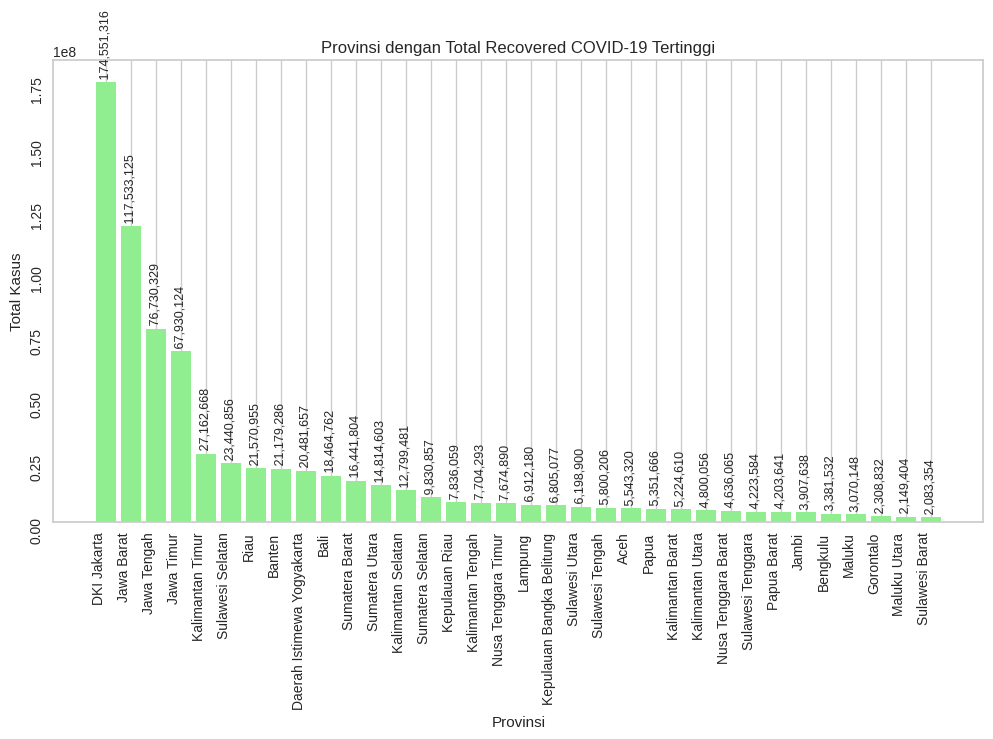

In [17]:
df_sorted = df_group.sort_values('Total Recovered', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(df_sorted.index, df_sorted['Total Recovered'], color='lightgreen')
plt.title('Provinsi dengan Total Recovered COVID-19 Tertinggi')
plt.xlabel('Provinsi')
plt.ylabel('Total Kasus')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.tick_params(labelrotation=90)

# Tambahkan nilai pada tiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f' {int(yval):,}', ha='center', va='bottom', fontsize=9, rotation=90)

plt.show()

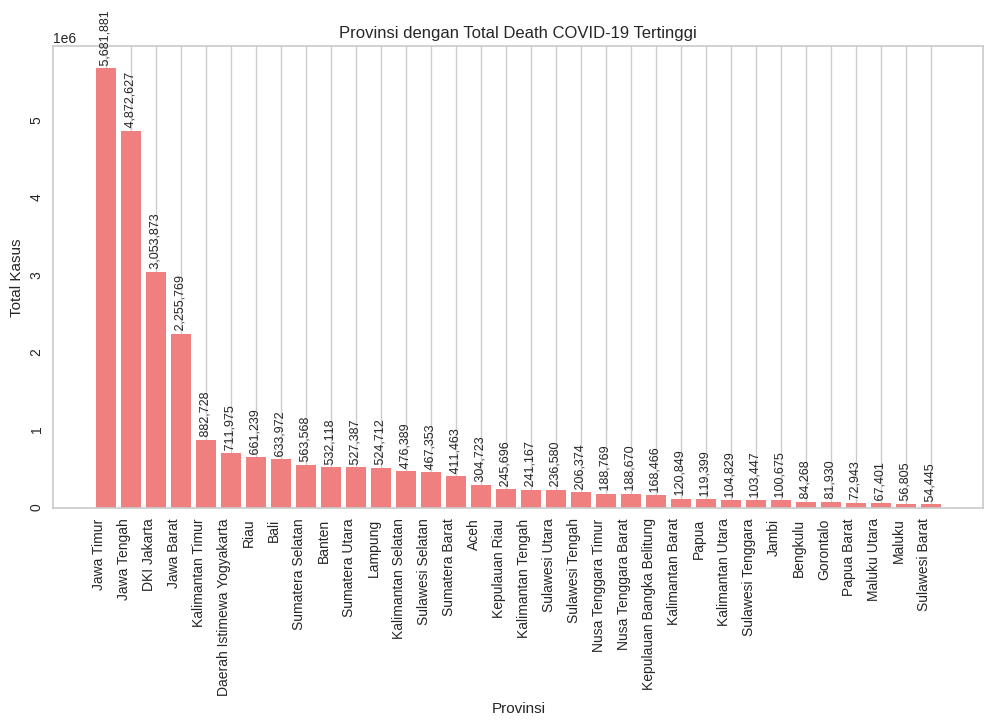

In [18]:
df_sorted = df_group.sort_values('Total Deaths', ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(df_sorted.index, df_sorted['Total Deaths'], color='lightcoral')
plt.title('Provinsi dengan Total Death COVID-19 Tertinggi')
plt.xlabel('Provinsi')
plt.ylabel('Total Kasus')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.tick_params(labelrotation=90)

# Tambahkan nilai pada tiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f' {int(yval):,}', ha='center', va='bottom', fontsize=9, rotation=90)

plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
df = df.drop(columns=[
    'Date','Location ISO Code', 'Location Level','City or Regency', 'Province', 'Country', 'Continent', 'Island', 'Time Zone', 'Special Status',
    'Area (km2)', 'Population', 'Population Density', 'New Cases per Million', 'Total Cases per Million', 'New Deaths per Million',
    'Total Deaths per Million', 'Total Deaths per 100rb', 'Growth Factor of New Cases', 'Growth Factor of New Deaths', 'Case Fatality Rate',
    'Case Recovered Rate', 'Total Regencies', 'Total Cities', 'Total Districts', 'Total Urban Villages', 'Total Rural Villages', 'Longitude', 'Latitude',
    'New Active Cases', 'New Cases', 'New Deaths', 'New Recovered', 'Total Active Cases'
])

In [8]:
df = df.drop(df[df['Location'] == 'Indonesia'].index)

In [10]:
df.isna().any()

,0
Location,False
Total Cases,False
Total Deaths,False
Total Recovered,False


In [12]:
df.duplicated().any()

np.True_

In [19]:
df.to_csv('covid_19_indonesia_time_series_all_clean.csv')